# 03 - Análisis estadístico del dataset - OULAD

**Propósito:** someter el dataset analítico consolidado (`dataset_analitico_oulad.parquet`,
32,593 × 37) a verificación formal de integridad, evaluación de normalidad, detección de
atípicos, estudio del mecanismo de datos faltantes y análisis bivariado contra la variable
objetivo, con pruebas de hipótesis y tamaños de efecto.

Complementa los Objetivos específicos 1 y 2, y sustenta las decisiones de la fase de
modelado (Objetivo específico 3). Los resultados quedan documentados en el reporte
`analisis_estadistico_oulad.tex`.

**Convención:** α = 0.05 en todas las pruebas. Dado n ≈ 32,000, cada contraste se
acompaña de su tamaño de efecto (con n grande, diferencias triviales resultan
estadísticamente significativas).

In [24]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from statsmodels.stats.diagnostic import lilliefors
import matplotlib.pyplot as plt

# --- Estilo grafico: 'Storytelling con datos' (Knaflic, 2015) ---
# Paleta de los reportes LinkedIn del autor: gris claro = contexto | azul #0073B1 = acento (una sola cosa importante por grafico)
# naranja luminoso = solo abandono/riesgo | degradado del mismo matiz para niveles ordenados | sin chartjunk
GRIS, GRISOS, TINTA = '#D4D4D4', '#9B9B9B', '#404040'
ACENTO, RIESGO = '#0073B1', '#E8833A'   # azul LinkedIn / naranja luminoso
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 9, 'text.color': TINTA,
    'axes.edgecolor': GRISOS, 'axes.labelcolor': TINTA, 'axes.titlecolor': TINTA,
    'xtick.color': GRISOS, 'ytick.color': GRISOS,
    'xtick.labelcolor': TINTA, 'ytick.labelcolor': TINTA,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 120, 'savefig.bbox': 'tight'})

def grad(n, c_claro='#C9E2F0', c_oscuro=ACENTO):
    """Degradado secuencial del mismo matiz (claro -> intenso) para niveles ordenados."""
    from matplotlib.colors import to_rgb
    a, b = np.array(to_rgb(c_claro)), np.array(to_rgb(c_oscuro))
    return [tuple(np.clip(a + (b - a) * i / max(n - 1, 1), 0, 1).tolist()) for i in range(n)]

def limpiar(ax, y_grid=True):
    ax.spines['left'].set_visible(False)
    ax.tick_params(length=0)
    if y_grid:
        ax.yaxis.grid(True, color='#ECECEC', lw=.7); ax.set_axisbelow(True)

PROCESSED_DIR = Path('../data/processed')
FIGS_DIR = Path('../reportes/figs'); FIGS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(PROCESSED_DIR / 'dataset_analitico_oulad.parquet')
print(f"Shape: {df.shape}")

Shape: (32593, 37)


## 1. Verificación de integridad

Duplicados (exactos y por llave compuesta), rangos admisibles de cada variable derivada
y consistencia lógica entre indicadores. Toda violación (> 0) debe investigarse antes
de continuar.

In [25]:
key = ['id_student', 'code_module', 'code_presentation']
print(f"Duplicados exactos:   {df.duplicated().sum()}")
print(f"Duplicados por llave: {df.duplicated(subset=key).sum()}")

chequeos = {
    'score_promedio fuera de [0,100]': ((df.score_promedio_temprano < 0) | (df.score_promedio_temprano > 100)).sum(),
    'score_min fuera de [0,100]':      ((df.score_min_temprano < 0) | (df.score_min_temprano > 100)).sum(),
    'frecuencia_acceso fuera de [0,1]':((df.frecuencia_acceso < 0) | (df.frecuencia_acceso > 1)).sum(),
    'dias_activos fuera de [1,28]':    ((df.dias_activos < 1) | (df.dias_activos > 28)).sum(),
    'semanas_activas fuera de [1,4]':  ((df.semanas_activas < 1) | (df.semanas_activas > 4)).sum(),
    'clics negativos':                 (df.total_clics < 0).sum(),
    'retiro antes de matricula':       (df.date_unregistration < df.date_registration).sum(),
    'dias_desde_ultima fuera de [0,27]':((df.dias_desde_ultima_interaccion < 0) | (df.dias_desde_ultima_interaccion > 27)).sum(),
    'inconsistencia sin_actividad vs nulos': (df.sin_actividad_ventana_temprana != df.dias_activos.isna().astype(int)).sum(),
    'sin_vle pero con actividad en ventana': ((df.sin_interaccion_vle == 1) & (df.sin_actividad_ventana_temprana == 0)).sum(),
    'inconsistencia abandono_implicito': (df.abandono_implicito_total != ((df.sin_interaccion_vle == 1) & (df.abandono == 0)).astype(int)).sum(),
}
for k, v in chequeos.items():
    print(f"{k:45s} {v}")
assert all(v == 0 for v in chequeos.values()), "Hay violaciones de integridad: revisar antes de continuar"
assert df.duplicated(subset=key).sum() == 0

Duplicados exactos:   0
Duplicados por llave: 0
score_promedio fuera de [0,100]               0
score_min fuera de [0,100]                    0
frecuencia_acceso fuera de [0,1]              0
dias_activos fuera de [1,28]                  0
semanas_activas fuera de [1,4]                0
clics negativos                               0
retiro antes de matricula                     0
dias_desde_ultima fuera de [0,27]             0
inconsistencia sin_actividad vs nulos         0
sin_vle pero con actividad en ventana         0
inconsistencia abandono_implicito             0


## 2. Anomalías temporales: momento del retiro

`date_unregistration` se mide en días relativos al inicio del curso. Se segmentan los
abandonos según el retiro ocurra **antes del día 0** (curso nunca iniciado), **dentro de
la ventana temprana** (días 0-27) o **después del día 28**. Esta segmentación condiciona
la definición operativa de la predicción temprana (riesgo de contaminación temporal).

In [26]:
u = df.date_unregistration.dropna()
n_ab = len(u)
print(f"Rango de date_unregistration: [{u.min():.0f}, {u.max():.0f}]")
print(f"Rango de date_registration:   [{df.date_registration.min():.0f}, {df.date_registration.max():.0f}]")

pre    = df[df.date_unregistration < 0]
en_vt  = df[(df.date_unregistration >= 0) & (df.date_unregistration < 28)]
post   = df[df.date_unregistration >= 28]
print(f"\nRetiros antes del dia 0:        {len(pre):5d} ({len(pre)/n_ab*100:.2f}% de los abandonos)")
print(f"  de ellos sin actividad en ventana: {pre.sin_actividad_ventana_temprana.sum()} ({pre.sin_actividad_ventana_temprana.mean()*100:.2f}%)")
print(f"  final_result: {pre.final_result.value_counts().to_dict()}")
print(f"Retiros en ventana [0,28):      {len(en_vt):5d} ({len(en_vt)/n_ab*100:.2f}%)")
print(f"Retiros despues del dia 28:     {len(post):5d} ({len(post)/n_ab*100:.2f}%)")

tarde = df[df.date_registration > 0]
print(f"\nMatriculas tardias (reg > 0): {len(tarde)} ({len(tarde)/len(df)*100:.2f}%); tasa de abandono {tarde.abandono.mean()*100:.2f}%")
print(f"Nulos en date_registration: {df.date_registration.isna().sum()}; tasa de abandono {df.loc[df.date_registration.isna(),'abandono'].mean()*100:.2f}%")

Rango de date_unregistration: [-365, 444]
Rango de date_registration:   [-322, 167]

Retiros antes del dia 0:         2678 (26.59% de los abandonos)
  de ellos sin actividad en ventana: 2574 (96.12%)
  final_result: {'Withdrawn': 2676, 'Fail': 2}
Retiros en ventana [0,28):       2362 (23.45%)
Retiros despues del dia 28:      5032 (49.96%)

Matriculas tardias (reg > 0): 234 (0.72%); tasa de abandono 20.09%
Nulos en date_registration: 45; tasa de abandono 86.67%


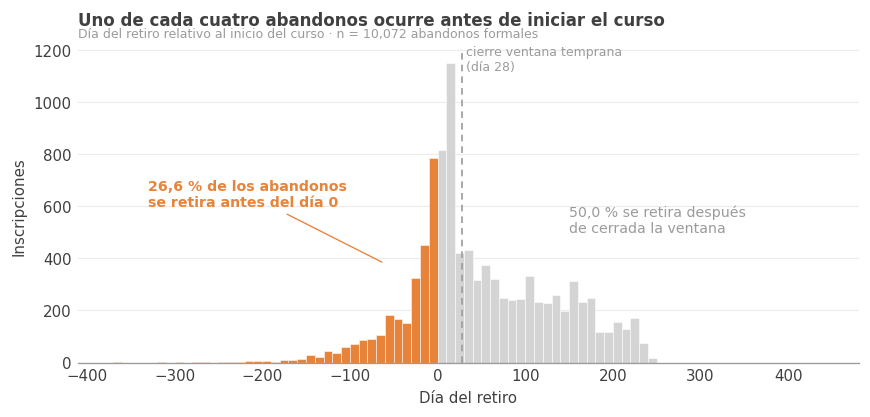

In [27]:
fig, ax = plt.subplots(figsize=(8.4, 3.4))
bins = np.arange(-370, 450, 10)
n_, b_, patches = ax.hist(u, bins=bins, color=GRIS, edgecolor='white', lw=.3)
for p, izq in zip(patches, b_[:-1]):
    if izq < 0: p.set_facecolor(RIESGO)   # retiros antes del dia 0
ax.axvline(28, color=GRISOS, lw=1, ls=(0, (4, 3)))
ax.text(32, ax.get_ylim()[1]*.93, 'cierre ventana temprana\n(día 28)', fontsize=7.5, color=GRISOS)
ax.annotate('26,6 % de los abandonos\nse retira antes del día 0', xy=(-60, 380), xytext=(-330, 600),
            fontsize=8.5, color=RIESGO, fontweight='bold',
            arrowprops=dict(arrowstyle='-', color=RIESGO, lw=.8))
ax.text(150, 500, '50,0 % se retira después\nde cerrada la ventana', fontsize=8.5, color=GRISOS)
limpiar(ax)
ax.set_title('Uno de cada cuatro abandonos ocurre antes de iniciar el curso',
             loc='left', fontsize=10, fontweight='bold', pad=14)
ax.text(0, 1.035, f'Día del retiro relativo al inicio del curso · n = {n_ab:,} abandonos formales',
        transform=ax.transAxes, fontsize=7.5, color=GRISOS)
ax.set_xlabel('Día del retiro'); ax.set_ylabel('Inscripciones')
plt.savefig(FIGS_DIR / 'fig_momento_retiro.pdf'); plt.show()

## 3. Análisis univariado y normalidad

### 3.1 Descriptivos
Media, DE, cuartiles, asimetría y exceso de curtosis (Fisher) sobre los casos observados.

In [28]:
numvars = ['total_clics','dias_activos','n_interacciones','promedio_clics_por_dia_activo',
           'frecuencia_acceso','dias_desde_ultima_interaccion','coef_variacion_clics',
           'semanas_activas','semanas_inactivas','n_evaluaciones_entregadas',
           'score_promedio_temprano','score_min_temprano','clics_quincena_1',
           'clics_quincena_2','variacion_actividad','num_of_prev_attempts','studied_credits']
desc = []
for v in numvars:
    s = df[v].dropna()
    q1, q2, q3 = s.quantile([.25, .5, .75])
    desc.append(dict(variable=v, n=len(s), media=s.mean(), de=s.std(), minimo=s.min(),
                     q1=q1, mediana=q2, q3=q3, maximo=s.max(),
                     asimetria=stats.skew(s), curtosis_exceso=stats.kurtosis(s)))
descriptivos = pd.DataFrame(desc).round(3)
descriptivos

,variable,n,media,de,minimo,q1,mediana,q3,maximo,asimetria,curtosis_exceso
0,total_clics,27886,279.043,327.940,1.000,72.000,179.000,370.000,6084.000,3.489,24.175
1,dias_activos,27886,10.820,6.992,1.000,5.000,10.000,16.000,28.000,0.582,-0.543
2,n_interacciones,27886,75.749,65.459,1.000,27.000,58.000,106.000,589.000,1.545,3.275
3,promedio_clics_por_dia_activo,27886,22.395,15.815,1.000,11.667,18.929,29.143,274.667,2.220,11.803
4,frecuencia_acceso,27886,0.386,0.250,0.036,0.179,0.357,0.571,1.000,0.582,-0.543
5,dias_desde_ultima_interaccion,27886,3.855,5.564,0.000,0.000,2.000,5.000,27.000,2.102,4.204
6,coef_variacion_clics,26443,0.959,0.341,0.000,0.740,0.922,1.151,3.494,0.586,1.412
7,semanas_activas,27886,3.327,0.967,1.000,3.000,4.000,4.000,4.000,-1.225,0.253
8,semanas_inactivas,27886,0.673,0.967,0.000,0.000,0.000,1.000,3.000,1.225,0.253
9,n_evaluaciones_entregadas,20114,1.158,0.424,1.000,1.000,1.000,1.000,4.000,2.748,7.130


### 3.2 Pruebas de normalidad

Hipótesis (para cada variable, α = 0.05):

$$H_0: \text{la variable proviene de una población normal} \qquad H_1: \text{no proviene de una población normal}$$

Se aplican tres pruebas complementarias: **Anderson-Darling** (sensible a colas),
**Lilliefors** (K-S con parámetros estimados de la muestra) y **K² de D'Agostino-Pearson**
(asimetría + curtosis). **Nota metodológica:** Shapiro-Wilk no es aplicable
(implementación limitada a n ≤ 5000) y, con n ≈ 28,000, cualquier prueba tiene potencia
casi 1 para desviaciones triviales; por eso la conclusión se apoya también en los Q-Q
plots y en la magnitud de asimetría/curtosis como tamaño de la desviación
(Montgomery & Runger, cap. 6; Wackerly et al., cap. 10).

In [29]:
filas = []
for v in numvars[:1] + numvars[1:]:  # todas
    s = df[v].dropna().values
    ad = stats.anderson(s, dist='norm')
    lf_stat, lf_p = lilliefors(s, dist='norm', pvalmethod='approx')
    k2, k2_p = stats.normaltest(s)
    filas.append(dict(variable=v, n=len(s),
                      AD_A2=ad.statistic, AD_critico_5pct=ad.critical_values[2],
                      Lilliefors_D=lf_stat, Lilliefors_p=lf_p,
                      DAgostino_K2=k2, DAgostino_p=k2_p,
                      decision='Se rechaza H0' if k2_p < 0.05 else 'No se rechaza H0'))
normalidad = pd.DataFrame(filas).round(4)
normalidad

C:\Users\luisj\AppData\Local\Temp\ipykernel_11780\4153207604.py:4: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad = stats.anderson(s, dist='norm')


,variable,n,AD_A2,AD_critico_5pct,Lilliefors_D,Lilliefors_p,DAgostino_K2,DAgostino_p,decision
0,total_clics,27886,1800.1928,0.752,0.1983,0.0,21763.7224,0.0,Se rechaza H0
1,dias_activos,27886,401.1156,0.752,0.1002,0.0,2039.4273,0.0,Se rechaza H0
2,n_interacciones,27886,905.5282,0.752,0.1267,0.0,8164.7163,0.0,Se rechaza H0
3,promedio_clics_por_dia_activo,27886,729.2558,0.752,0.1020,0.0,14539.2349,0.0,Se rechaza H0
4,frecuencia_acceso,27886,401.1156,0.752,0.1002,0.0,2039.4273,0.0,Se rechaza H0
5,dias_desde_ultima_interaccion,27886,2772.3976,0.752,0.2459,0.0,11355.2604,0.0,Se rechaza H0
6,coef_variacion_clics,26443,144.0902,0.752,0.0494,0.0,2118.3389,0.0,Se rechaza H0
7,semanas_activas,27886,3551.6756,0.752,0.3611,0.0,4488.8528,0.0,Se rechaza H0
8,semanas_inactivas,27886,3551.6756,0.752,0.3611,0.0,4488.8528,0.0,Se rechaza H0
9,n_evaluaciones_entregadas,20114,5702.9894,0.752,0.5106,0.0,11167.1278,0.0,Se rechaza H0


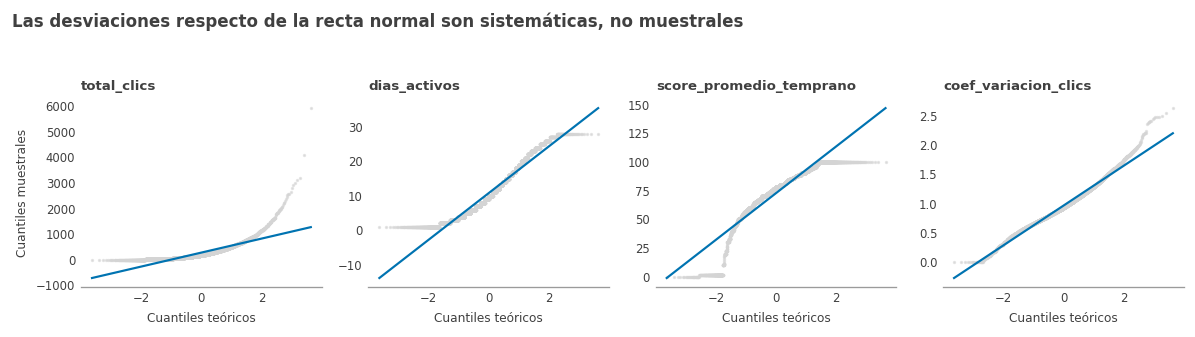

In [30]:
vars_qq = ['total_clics', 'dias_activos', 'score_promedio_temprano', 'coef_variacion_clics']
fig, axes = plt.subplots(1, 4, figsize=(10, 2.8))
for ax, v in zip(axes, vars_qq):
    sub = df[v].dropna().sample(5000, random_state=42)
    (osm, osr), (m, b, r) = stats.probplot(sub, dist='norm')
    ax.plot(osm, osr, '.', ms=2, color=GRIS, alpha=.6)
    ax.plot(osm, m*osm + b, color=ACENTO, lw=1.3)
    ax.set_title(v, loc='left', fontsize=8, fontweight='bold')
    ax.set_xlabel('Cuantiles teóricos', fontsize=7.3); ax.tick_params(labelsize=7)
    limpiar(ax, y_grid=False)
axes[0].set_ylabel('Cuantiles muestrales', fontsize=7.3)
fig.suptitle('Las desviaciones respecto de la recta normal son sistemáticas, no muestrales',
             x=.01, ha='left', fontsize=10, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, .93]); plt.savefig(FIGS_DIR / 'fig_qq.pdf'); plt.show()

**Conclusión:** las tres pruebas rechazan H₀ para todas las variables (p < 0.001) y los
Q-Q muestran desviaciones sistemáticas de gran magnitud. En consecuencia: contrastes
bivariados con **Mann-Whitney**, correlaciones con **Spearman**, y transformación
**log(1+x)** de las variables de clics para los modelos sensibles a escala.

## 4. Valores atípicos

Dos criterios complementarios: regla de **Tukey** (1.5×IQR moderado, 3×IQR extremo;
Tukey, 1977) y **z-robusto** basado en mediana y MAD con umbral 3.5 (Iglewicz &
Hoaglin, 1993), inmune a la contaminación de los propios atípicos.

In [31]:
filas = []
for v in numvars:
    s = df[v].dropna()
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    tk15 = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    tk30 = ((s < q1 - 3.0*iqr) | (s > q3 + 3.0*iqr)).sum()
    mad = stats.median_abs_deviation(s, scale='normal')
    zr = (np.abs((s - s.median()) / mad) > 3.5).sum() if mad > 0 else 0
    filas.append(dict(variable=v, n=len(s), tukey_1_5=int(tk15), pct_1_5=round(100*tk15/len(s),2),
                      tukey_3_0=int(tk30), z_robusto_3_5=int(zr)))
atipicos = pd.DataFrame(filas)
atipicos

,variable,n,tukey_1_5,pct_1_5,tukey_3_0,z_robusto_3_5
0,total_clics,27886,1667,5.98,490,1523
1,dias_activos,27886,0,0.00,0,0
2,n_interacciones,27886,962,3.45,111,666
3,promedio_clics_por_dia_activo,27886,1022,3.66,223,663
4,frecuencia_acceso,27886,0,0.00,0,0
5,dias_desde_ultima_interaccion,27886,2285,8.19,880,2285
6,coef_variacion_clics,26443,730,2.76,40,216
7,semanas_activas,27886,2243,8.04,0,0
8,semanas_inactivas,27886,2243,8.04,0,0
9,n_evaluaciones_entregadas,20114,2707,13.46,2707,0


In [32]:
# Caracterizacion de los atipicos extremos de total_clics: ¿ruido o señal?
s = df.total_clics.dropna(); q1, q3 = s.quantile([.25, .75])
umbral = q3 + 3*(q3 - q1)
ext = df[df.total_clics > umbral]
print(f"total_clics > {umbral:.0f} (Tukey 3xIQR): {len(ext)} casos")
print(f"Tasa de abandono en atipicos extremos: {ext.abandono.mean()*100:.2f}% (global: {df.abandono.mean()*100:.2f}%)")

total_clics > 1264 (Tukey 3xIQR): 490 casos
Tasa de abandono en atipicos extremos: 8.37% (global: 30.90%)


**Decisión:** los atípicos superiores de clics corresponden a estudiantes altamente
comprometidos (abandono muy inferior al global) — son señal, no error. En variables de
conteo concentradas (IQR = 0) el criterio de Tukey carece de interpretación. **Se
conservan todos los atípicos**, con log(1+x) como salvaguarda para modelos sensibles a
escala; sin winsorización ni eliminación.

## 5. Mecanismo de los datos faltantes

Los faltantes forman **bloques estructurales anidados** (sin actividad → sin variables
de interacción; un solo día activo → sin coef. de variación; etc.). Al ser deterministas,
la prueba MCAR de Little carece de objeto; la pregunta correcta es si **la condición que
genera el faltante está asociada al abandono** (Little & Rubin, 2019). Para cada
indicador de faltante M:

$$H_0: M \perp \text{abandono} \qquad H_1: M \not\perp \text{abandono}$$

χ² de independencia (verificando Cochran: esperadas ≥ 5) + V de Cramér.

In [33]:
def cramers_v(tab):
    chi2 = stats.chi2_contingency(tab)[0]
    n = tab.values.sum(); r, c_ = tab.shape
    return np.sqrt(chi2 / (n * (min(r, c_) - 1)))

mA = df.dias_activos.isna()                       # sin actividad en ventana
mB = df.score_promedio_temprano.isna()            # sin entregas tempranas
mC = df.coef_variacion_clics.isna() & ~mA         # un solo dia activo
mD = df.variacion_actividad.isna() & ~mA          # quincena 1 sin clics
mI = df.imd_band.isna()
mR = df.date_registration.isna()
print(f"Sin actividad pero CON entrega temprana (canal no-VLE): {(mA & ~mB).sum()} casos")

filas = []
for nombre, m in [('sin_actividad_ventana', mA), ('sin_entregas_tempranas', mB),
                  ('un_solo_dia_activo', mC), ('quincena1_sin_clics', mD),
                  ('imd_band_faltante', mI), ('date_registration_faltante', mR)]:
    tab = pd.crosstab(m, df.abandono)
    chi2, p, gl, esp = stats.chi2_contingency(tab)
    filas.append(dict(indicador=nombre, n_faltante=int(m.sum()),
                      tasa_ab_faltante=round(df.loc[m, 'abandono'].mean()*100, 2),
                      tasa_ab_no_faltante=round(df.loc[~m, 'abandono'].mean()*100, 2),
                      chi2=round(chi2, 1), gl=gl, p=p, V_cramer=round(cramers_v(tab), 3),
                      esperada_min=round(esp.min(), 1)))
faltantes_assoc = pd.DataFrame(filas)
faltantes_assoc

Sin actividad pero CON entrega temprana (canal no-VLE): 91 casos


,indicador,n_faltante,tasa_ab_faltante,tasa_ab_no_faltante,chi2,gl,p,V_cramer,esperada_min
0,sin_actividad_ventana,4707,79.12,22.76,5986.6,1,0.000000e+00,0.429,1454.6
1,sin_entregas_tempranas,12491,50.05,19.00,3476.7,1,0.000000e+00,0.327,3860.0
2,un_solo_dia_activo,1443,40.68,30.45,67.1,1,2.567675e-16,0.045,445.9
3,quincena1_sin_clics,1461,28.75,31.00,3.2,1,7.267475e-02,0.010,451.5
4,imd_band_faltante,1111,21.15,31.25,50.7,1,1.055628e-12,0.039,343.3
5,date_registration_faltante,45,86.67,30.83,63.0,1,2.029538e-15,0.044,13.9


In [34]:
# imd_band: ¿MCAR o MAR? Contraste del indicador de faltante contra la region
tab = pd.crosstab(mI, df.region)
chi2, p, gl, esp = stats.chi2_contingency(tab)
print(f"imd_band faltante vs region: chi2 = {chi2:.1f}, gl = {gl}, p = {p:.3g}, V = {cramers_v(tab):.3f}")
print("\n% de imd_band faltante por region:")
print(df.groupby('region')['imd_band'].apply(lambda s: round(s.isna().mean()*100, 2)).sort_values(ascending=False))

imd_band faltante vs region: chi2 = 9610.2, gl = 12, p = 0, V = 0.543

% de imd_band faltante por region:
region
North Region            40.10
Ireland                 22.47
South Region             1.55
West Midlands Region     1.51
Scotland                 0.35
Yorkshire Region         0.25
South West Region        0.21
North Western Region     0.17
East Anglian Region      0.00
East Midlands Region     0.00
London Region            0.00
South East Region        0.00
Wales                    0.00
Name: imd_band, dtype: float64


**Conclusión:** los bloques de actividad y desempeño son **MNAR informativos**
(V = 0.429 y V = 0.327: la ausencia es una de las señales de riesgo más fuertes del
dataset) → **prohibida la imputación por media/mediana**; se usa indicador + centinela
cero donde el cero es semánticamente exacto, y NaN nativo en XGBoost/LightGBM.
`imd_band` es **MAR condicional a la región** (concentrado en North Region e Ireland,
donde el IMD inglés no aplica) → categoría explícita "No disponible".

## 6. Análisis bivariado

### 6.1 Numéricas vs. abandono — Mann-Whitney + r de rango biserial

$$H_0: P(X_{ab} > X_{no}) = 1/2 \qquad H_1: P(X_{ab} > X_{no}) \neq 1/2$$

Tamaño de efecto: $r_{rb} = 2U/(n_1 n_2) - 1$ (positivo ⇒ valores mayores en el grupo
de abandono).

In [35]:
filas = []
for v in numvars:
    a = df.loc[df.abandono == 1, v].dropna()
    b = df.loc[df.abandono == 0, v].dropna()
    U, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    filas.append(dict(variable=v, mediana_abandono=a.median(), mediana_no_abandono=b.median(),
                      U=U, p=p, r_rb=round(2*U/(len(a)*len(b)) - 1, 3)))
biv_num = pd.DataFrame(filas).sort_values('r_rb', key=abs, ascending=False)
biv_num

,variable,mediana_abandono,mediana_no_abandono,U,p,r_rb
10,score_promedio_temprano,70.000000,78.000000,22589837.5,2.789267e-153,-0.274
11,score_min_temprano,69.000000,78.000000,22885365.5,5.607330e-143,-0.264
5,dias_desde_ultima_interaccion,3.000000,1.000000,85179068.0,2.212423e-203,0.246
1,dias_activos,7.000000,10.000000,52622548.5,6.297131e-172,-0.230
4,frecuencia_acceso,0.250000,0.357143,52622548.5,6.297131e-172,-0.230
16,studied_credits,60.000000,60.000000,137929335.5,3.256381e-250,0.216
2,n_interacciones,43.000000,63.000000,53962175.5,6.067522e-144,-0.211
13,clics_quincena_2,57.000000,94.000000,54112849.5,4.775158e-141,-0.208
8,semanas_inactivas,1.000000,0.000000,82324376.5,1.705373e-175,0.204
7,semanas_activas,3.000000,4.000000,54398847.5,1.705373e-175,-0.204


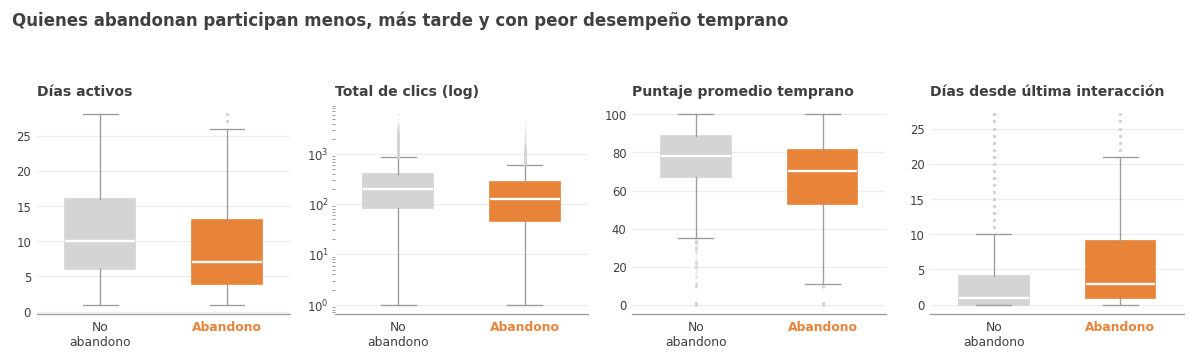

In [36]:
vars_box = [('dias_activos', 'Días activos'), ('total_clics', 'Total de clics (log)'),
            ('score_promedio_temprano', 'Puntaje promedio temprano'),
            ('dias_desde_ultima_interaccion', 'Días desde última interacción')]
fig, axes = plt.subplots(1, 4, figsize=(10, 3.0))
for ax, (v, tit) in zip(axes, vars_box):
    d0 = df.loc[df.abandono == 0, v].dropna(); d1 = df.loc[df.abandono == 1, v].dropna()
    bp = ax.boxplot([d0, d1], widths=.55, patch_artist=True,
                    flierprops=dict(marker='.', ms=1.2, alpha=.15, markerfacecolor=GRIS, markeredgecolor=GRIS),
                    medianprops=dict(color='white', lw=1.4),
                    whiskerprops=dict(color=GRISOS, lw=.8), capprops=dict(color=GRISOS, lw=.8))
    bp['boxes'][0].set(facecolor=GRIS, edgecolor=GRIS)
    bp['boxes'][1].set(facecolor=RIESGO, edgecolor=RIESGO)
    if v == 'total_clics': ax.set_yscale('log')
    ax.set_xticks([1, 2]); ax.set_xticklabels(['No\nabandono', 'Abandono'], fontsize=7.4)
    ax.get_xticklabels()[1].set(color=RIESGO, fontweight='bold')
    ax.set_title(tit, loc='left', fontsize=8.4, fontweight='bold')
    limpiar(ax); ax.tick_params(axis='y', labelsize=7)
fig.suptitle('Quienes abandonan participan menos, más tarde y con peor desempeño temprano',
             x=.01, ha='left', fontsize=10, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, .92]); plt.savefig(FIGS_DIR / 'fig_boxplots_abandono.pdf'); plt.show()

### 6.2 Categóricas vs. abandono — χ² + V de Cramér + residuos estandarizados

In [37]:
catvars = ['gender', 'age_band', 'highest_education', 'imd_band', 'disability', 'region', 'code_module']
filas = []
for v in catvars:
    tab = pd.crosstab(df[v], df.abandono)
    chi2, p, gl, esp = stats.chi2_contingency(tab)
    filas.append(dict(variable=v, niveles=tab.shape[0], chi2=round(chi2, 2), gl=gl, p=p,
                      V_cramer=round(cramers_v(tab), 3), esperada_min=round(esp.min(), 1)))
biv_cat = pd.DataFrame(filas).sort_values('V_cramer', ascending=False)
biv_cat

,variable,niveles,chi2,gl,p,V_cramer,esperada_min
6,code_module,7,997.22,6,3.570705e-212,0.175,231.1
3,imd_band,10,198.44,9,7.032767e-38,0.079,792.4
2,highest_education,5,197.38,4,1.373259e-41,0.078,96.7
5,region,13,194.51,12,4.427004e-35,0.077,365.9
4,disability,2,104.72,1,1.405011e-24,0.057,977.8
1,age_band,3,37.37,2,7.663492e-09,0.034,66.7
0,gender,2,5.43,1,1.983811e-02,0.013,4548.2


In [38]:
# Residuos estandarizados ajustados: localizan las celdas responsables de la asociacion
def residuos_ajustados(v):
    tab = pd.crosstab(df[v], df.abandono)
    chi2, p, gl, esp = stats.chi2_contingency(tab)
    n = tab.values.sum()
    pf = tab.sum(axis=1) / n; pc = tab.sum(axis=0) / n
    return ((tab - esp) / np.sqrt(esp * np.outer(1 - pf, 1 - pc))).round(2)

for v in ['imd_band', 'highest_education', 'age_band']:
    print(f"\n=== {v} ===")
    print(residuos_ajustados(v))


=== imd_band ===
abandono     0     1
imd_band            
0-10%    -7.43  7.43
10-20    -5.19  5.19
20-30%   -6.46  6.46
30-40%    0.92 -0.92
40-50%   -0.66  0.66
50-60%    3.26 -3.26
60-70%    2.34 -2.34
70-80%    4.66 -4.66
80-90%    4.13 -4.13
90-100%   6.36 -6.36

=== highest_education ===
abandono                         0      1
highest_education                        
A Level or Equivalent         8.21  -8.21
HE Qualification              6.39  -6.39
Lower Than A Level          -12.43  12.43
No Formal quals              -4.88   4.88
Post Graduate Qualification   2.92  -2.92

=== age_band ===
abandono     0     1
age_band            
0-35     -6.01  6.01
35-55     5.71 -5.71
55<=      1.88 -1.88


### 6.3 Correlación de Spearman entre predictoras — redundancia

Pares con |rho| > 0.8:
  total_clics ~ dias_activos: rho = 0.861
  total_clics ~ n_interacciones: rho = 0.949
  total_clics ~ frecuencia_acceso: rho = 0.861
  total_clics ~ clics_quincena_1: rho = 0.869
  total_clics ~ clics_quincena_2: rho = 0.894
  dias_activos ~ n_interacciones: rho = 0.918
  dias_activos ~ frecuencia_acceso: rho = 1.000
  dias_activos ~ clics_quincena_1: rho = 0.804
  n_interacciones ~ frecuencia_acceso: rho = 0.918
  n_interacciones ~ clics_quincena_1: rho = 0.861
  n_interacciones ~ clics_quincena_2: rho = 0.843
  frecuencia_acceso ~ clics_quincena_1: rho = 0.804
  semanas_activas ~ semanas_inactivas: rho = -1.000
  score_promedio_temprano ~ score_min_temprano: rho = 0.986


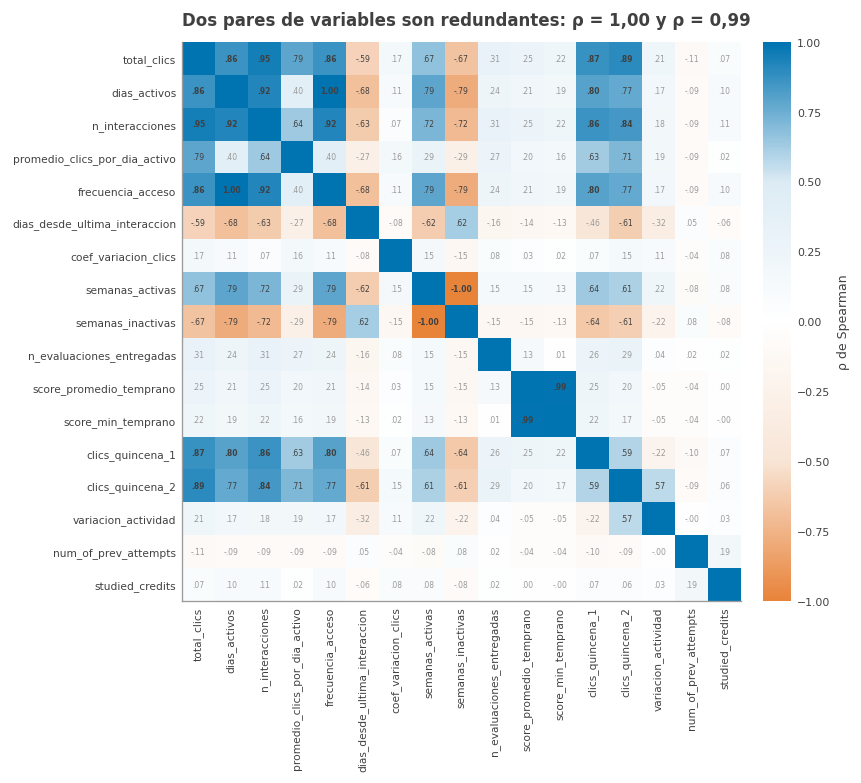

In [39]:
corr = df[numvars].corr(method='spearman')
print("Pares con |rho| > 0.8:")
for i in range(len(numvars)):
    for j in range(i + 1, len(numvars)):
        if abs(corr.iloc[i, j]) > 0.8:
            print(f"  {numvars[i]} ~ {numvars[j]}: rho = {corr.iloc[i, j]:.3f}")

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('sobrio', ['#E8833A', '#F8E5D6', '#FFFFFF', '#DCEBF4', '#0073B1'])
fig, ax = plt.subplots(figsize=(7.8, 6.6))
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(numvars))); ax.set_yticks(range(len(numvars)))
ax.set_xticklabels(numvars, rotation=90, fontsize=6.4); ax.set_yticklabels(numvars, fontsize=6.4)
for i in range(len(numvars)):
    for j in range(len(numvars)):
        v_ = corr.iloc[i, j]
        if i != j:
            ax.text(j, i, f'{v_:.2f}'.replace('0.', '.').replace('-0.', '-.'),
                    ha='center', va='center', fontsize=4.6,
                    color=TINTA if abs(v_) > .5 else '#9A9A9A',
                    fontweight='bold' if abs(v_) > .8 else 'normal')
ax.set_title('Dos pares de variables son redundantes: ρ = 1,00 y ρ = 0,99',
             loc='left', fontsize=10, fontweight='bold', pad=10)
ax.tick_params(length=0)
cb = plt.colorbar(im, fraction=.046, pad=.03); cb.set_label('ρ de Spearman', fontsize=7.5)
cb.outline.set_visible(False); cb.ax.tick_params(labelsize=6.5, length=0)
plt.tight_layout(); plt.savefig(FIGS_DIR / 'fig_spearman.pdf'); plt.show()

## 7. Análisis multivariado

Perspectiva conjunta sobre las **seis variables de interacción** de la subpoblación con
actividad (n = 27,886; clics en log(1+x)): normalidad multivariada, atípicos
multivariados, contraste de Hotelling entre clases, VIF y componentes principales.
Referencias: Johnson & Wichern, *Applied Multivariate Statistical Analysis* (texto
clásico adicional a los del curso); Mardia (1970); Rousseeuw & Van Driessen (1999).

In [40]:
from sklearn.covariance import MinCovDet
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pingouin as pg   # pip install pingouin

df['log_ratio_actividad'] = np.log((df.clics_quincena_2 + 1) / (df.clics_quincena_1 + 1))
MV = ['log1p_total_clics', 'dias_activos', 'log1p_prom_clics',
      'dias_desde_ultima_interaccion', 'semanas_activas', 'log_ratio_actividad']
sub = df[df.dias_activos.notna()].copy()
sub['log1p_total_clics'] = np.log1p(sub.total_clics)
sub['log1p_prom_clics'] = np.log1p(sub.promedio_clics_por_dia_activo)
Xmv = sub[MV].values
print(f"Subpoblacion con actividad: n = {len(sub)}, p = {len(MV)}")

Subpoblacion con actividad: n = 27886, p = 6


### 7.1 Normalidad multivariada

$$H_0: \mathbf{X} \sim N_p(\boldsymbol{\mu}, \boldsymbol{\Sigma}) \qquad H_1: \mathbf{X} \not\sim N_p$$

Henze-Zirkler + asimetría y curtosis de Mardia, sobre submuestra de 5,000 (semilla
fija; ambas pruebas son O(n²)). α = 0.05.

In [41]:
rng = np.random.default_rng(42)
idx = rng.choice(len(Xmv), 5000, replace=False)
hz = pg.multivariate_normality(pd.DataFrame(Xmv[idx], columns=MV), alpha=.05)
print(f"Henze-Zirkler: HZ = {hz.hz:.3f}, p = {hz.pval:.3g} -> "
      f"{'se RECHAZA' if not hz.normal else 'no se rechaza'} la normalidad multivariada")

Xc = Xmv[idx] - Xmv[idx].mean(0)
S = np.cov(Xc.T); Sinv = np.linalg.inv(S)
n, p = Xc.shape
G = Xc @ Sinv @ Xc.T
b1 = (G**3).sum() / n**2
b2 = (np.diag(G)**2).mean()
chi_b1 = n*b1/6; gl_b1 = p*(p+1)*(p+2)//6
z_b2 = (b2 - p*(p+2)) / np.sqrt(8*p*(p+2)/n)
print(f"Mardia asimetria: b1 = {b1:.2f} (chi2 = {chi_b1:.0f}, gl = {gl_b1}, p = {stats.chi2.sf(chi_b1, gl_b1):.3g})")
print(f"Mardia curtosis:  b2 = {b2:.2f} vs {p*(p+2)} esperado (z = {z_b2:.1f}, p = {2*stats.norm.sf(abs(z_b2)):.3g})")

Henze-Zirkler: HZ = 60.339, p = 0 -> se RECHAZA la normalidad multivariada
Mardia asimetria: b1 = 18.27 (chi2 = 15229, gl = 56, p = 0)
Mardia curtosis:  b2 = 68.45 vs 48 esperado (z = 73.8, p = 0)


### 7.2 Atípicos multivariados — Mahalanobis robusta (MCD)

El estimador MCD evita el enmascaramiento de los atípicos sobre media y covarianza
clásicas. Umbral de referencia χ²(0.975, 6) — conservador dado el rechazo de la
normalidad conjunta.

Atipicos multivariados: 8,822 (31.6%) con umbral 14.45
Tasa de abandono: atipicos 32.7% vs resto 18.2%  (chi2 p = 1.73e-159)
Decision: se conservan — las configuraciones conjuntas inusuales son señal de riesgo


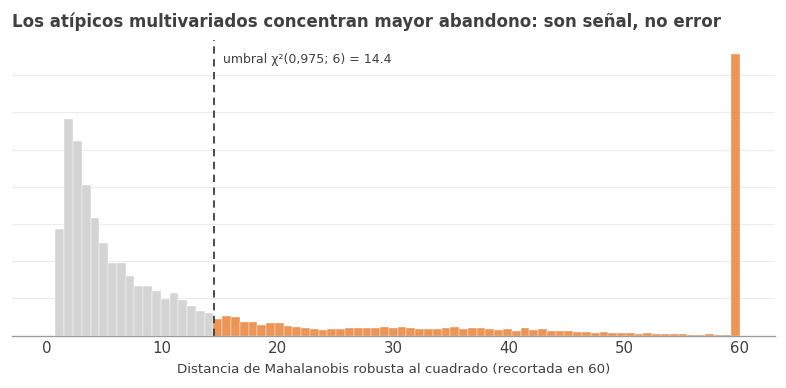

In [42]:
mcd = MinCovDet(support_fraction=.75, random_state=42).fit(Xmv)
d2 = mcd.mahalanobis(Xmv)
umbral = stats.chi2.ppf(.975, len(MV))
atip = d2 > umbral
sub['atipico_mv'] = atip
tab = pd.crosstab(sub.atipico_mv, sub.abandono)
chi2_, p_, _, _ = stats.chi2_contingency(tab)
print(f"Atipicos multivariados: {atip.sum():,} ({atip.mean()*100:.1f}%) con umbral {umbral:.2f}")
print(f"Tasa de abandono: atipicos {sub.loc[atip,'abandono'].mean()*100:.1f}% vs "
      f"resto {sub.loc[~atip,'abandono'].mean()*100:.1f}%  (chi2 p = {p_:.3g})")
print("Decision: se conservan — las configuraciones conjuntas inusuales son señal de riesgo")

fig, ax = plt.subplots(figsize=(8.2, 3.2))
bins = np.linspace(0, 60, 80)
ax.hist(np.clip(d2, 0, 60)[~atip], bins=bins, color=GRIS, edgecolor='white', lw=.25)
ax.hist(np.clip(d2, 0, 60)[atip], bins=bins, color=RIESGO, edgecolor='white', lw=.25, alpha=.85)
ax.axvline(umbral, color=TINTA, lw=1.1, ls=(0, (4, 3)))
ax.text(umbral+.8, ax.get_ylim()[1]*.92, f'umbral χ²(0,975; 6) = {umbral:.1f}', fontsize=7.5)
limpiar(ax); ax.set_yticklabels([])
ax.set_xlabel('Distancia de Mahalanobis robusta al cuadrado (recortada en 60)', fontsize=8)
ax.set_title('Los atípicos multivariados concentran mayor abandono: son señal, no error',
             loc='left', fontsize=10, fontweight='bold', pad=8)
plt.savefig(FIGS_DIR / 'fig_mahalanobis.pdf'); plt.show()

### 7.3 Contraste de Hotelling entre clases

$$H_0: \boldsymbol{\mu}_{ab} = \boldsymbol{\mu}_{no} \qquad H_1: \boldsymbol{\mu}_{ab} \neq \boldsymbol{\mu}_{no}$$

Válido asintóticamente (TCL multivariado, n grande) pese al rechazo de la normalidad.
Tamaño de efecto: distancia de Mahalanobis D entre centroides. Box M se omite
deliberadamente (hipersensible con n grande; el resultado asintótico no depende de él).

In [43]:
g1 = Xmv[sub.abandono.values == 1]; g0 = Xmv[sub.abandono.values == 0]
n1, n0 = len(g1), len(g0)
m1, m0 = g1.mean(0), g0.mean(0)
Sp = ((n1-1)*np.cov(g1.T) + (n0-1)*np.cov(g0.T)) / (n1+n0-2)
diff = m1 - m0
T2 = (n1*n0/(n1+n0)) * diff @ np.linalg.inv(Sp) @ diff
F = (n1+n0-p-1) / ((n1+n0-2)*p) * T2
print(f"Hotelling T2 = {T2:.1f} | F({p}, {n1+n0-p-1}) = {F:.1f} | p = {stats.f.sf(F, p, n1+n0-p-1):.3g}")
D2 = diff @ np.linalg.inv(Sp) @ diff
print(f"Distancia de Mahalanobis entre centroides: D = {np.sqrt(D2):.3f} (separacion moderada)")

Hotelling T2 = 1397.9 | F(6, 27879) = 232.9 | p = 1.65e-291
Distancia de Mahalanobis entre centroides: D = 0.534 (separacion moderada)


### 7.4 Multicolinealidad — VIF

In [44]:
NUMV = ['total_clics','dias_activos','n_interacciones','promedio_clics_por_dia_activo',
        'dias_desde_ultima_interaccion','semanas_activas','n_evaluaciones_entregadas',
        'score_promedio_temprano','clics_quincena_1','clics_quincena_2',
        'log_ratio_actividad','num_of_prev_attempts','studied_credits']
comp = df[NUMV].dropna()
Xv = StandardScaler().fit_transform(comp)
vifs = pd.Series([variance_inflation_factor(Xv, i) for i in range(Xv.shape[1])],
                 index=NUMV).sort_values(ascending=False)
print(f"VIF (n = {len(comp)} casos completos):"); print(vifs.round(2))
print("\nHallazgo: total_clics = q1 + q2 EXACTAMENTE (VIF infinito en las tres).")
print("Decision (modelos lineales): quincenas en lugar del total; dias_activos frente a n_interacciones.")

d:\proyecto-grado\prediccion-desercion-oulad\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


VIF (n = 20011 casos completos):
total_clics                       inf
clics_quincena_1                  inf
clics_quincena_2                  inf
n_interacciones                  9.35
dias_activos                     6.86
promedio_clics_por_dia_activo    4.08
semanas_activas                  2.52
dias_desde_ultima_interaccion    2.32
log_ratio_actividad              2.01
n_evaluaciones_entregadas        1.18
score_promedio_temprano          1.07
num_of_prev_attempts             1.04
studied_credits                  1.03
dtype: float64

Hallazgo: total_clics = q1 + q2 EXACTAMENTE (VIF infinito en las tres).
Decision (modelos lineales): quincenas en lugar del total; dias_activos frente a n_interacciones.


### 7.5 Componentes principales (descriptivo)

Varianza explicada: [58.2 19.  14.   5.7  2.8  0.3] | acumulada 2 comp.: 77.3%
                                 PC1    PC2    PC3
log1p_total_clics              0.508 -0.194  0.226
dias_activos                   0.450 -0.179 -0.236
log1p_prom_clics               0.367 -0.222  0.732
dias_desde_ultima_interaccion -0.429 -0.392  0.278
semanas_activas                0.454 -0.023 -0.430
log_ratio_actividad            0.121  0.852  0.308

Lectura: PC1 = volumen/extension de la participacion; PC2 = tendencia entre 
quincenas (log_ratio); PC3 = intensidad por dia activo. El ACP es descriptivo: 
no se usara como reduccion de dimensionalidad (interpretabilidad por variable original).


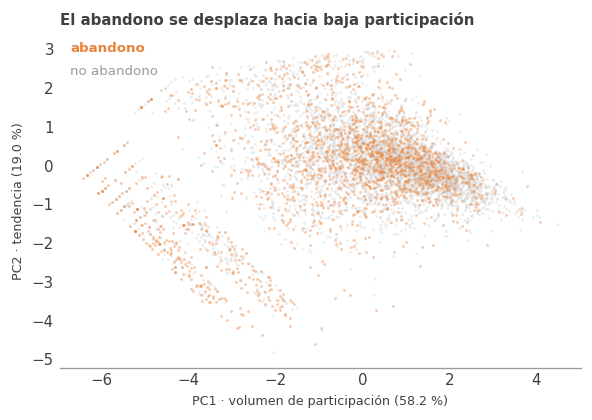

In [45]:
Z = StandardScaler().fit_transform(Xmv)
pca = PCA(random_state=42).fit(Z)
var = pca.explained_variance_ratio_ * 100
print(f"Varianza explicada: {np.round(var, 1)} | acumulada 2 comp.: {var[:2].sum():.1f}%")
print(pd.DataFrame(pca.components_[:3].T, index=MV, columns=['PC1','PC2','PC3']).round(3))
print("\nLectura: PC1 = volumen/extension de la participacion; PC2 = tendencia entre",
      "\nquincenas (log_ratio); PC3 = intensidad por dia activo. El ACP es descriptivo:",
      "\nno se usara como reduccion de dimensionalidad (interpretabilidad por variable original).")

sc = pca.transform(Z)[:, :2]
rng = np.random.default_rng(42)
i0 = rng.choice(np.where(sub.abandono.values == 0)[0], 4000, replace=False)
i1 = rng.choice(np.where(sub.abandono.values == 1)[0], 2000, replace=False)
fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.scatter(sc[i0, 0], sc[i0, 1], s=3, color=GRIS, alpha=.4, lw=0)
ax.scatter(sc[i1, 0], sc[i1, 1], s=3, color=RIESGO, alpha=.4, lw=0)
ax.text(.02, .95, 'abandono', transform=ax.transAxes, fontsize=8, color=RIESGO, fontweight='bold')
ax.text(.02, .88, 'no abandono', transform=ax.transAxes, fontsize=8, color=GRISOS)
ax.set_xlabel(f'PC1 · volumen de participación ({var[0]:.1f} %)', fontsize=7.6)
ax.set_ylabel(f'PC2 · tendencia ({var[1]:.1f} %)', fontsize=7.6)
ax.set_title('El abandono se desplaza hacia baja participación', loc='left', fontsize=9, fontweight='bold')
limpiar(ax, y_grid=False)
plt.savefig(FIGS_DIR / 'fig_pca.pdf'); plt.show()

## 8. Síntesis de decisiones para el Objetivo 3

1. **Momento del retiro:** 26.6% de abandonos antes del día 0 y 23.4% dentro de la
   ventana → definir explícitamente el evento a predecir (restringir a retiro ≥ día 28,
   reportar segmentado, o excluir pre-inicio) para evitar contaminación temporal.
2. **Normalidad rechazada en todas las variables** → no paramétricos, Spearman,
   log(1+x) en clics para modelos de escala.
3. **Atípicos conservados** (son señal: abandono 8.4% en clics extremos).
4. **Faltantes MNAR informativos** → indicador + centinela cero / NaN nativo; nunca
   media o mediana. `imd_band` → categoría "No disponible".
5. **Redundancia exacta:** eliminar `frecuencia_acceso` (≡ dias_activos/28, ρ = 1.000)
   y `score_min_temprano` (ρ = 0.986 con score_promedio).
6. **Reconstruir** `variacion_actividad` como log((clics_q2 + 1)/(clics_q1 + 1)).
7. **Candidata a exclusión:** `coef_variacion_clics` (p = 0.058, r_rb = 0.016).
8. **Colinealidad exacta adicional (VIF):** total_clics ≡ q1 + q2 (VIF ∞) — en
   modelos lineales usar las quincenas y no el total; dias_activos frente a
   n_interacciones (VIF 9.4).
9. **Multivariado:** normalidad conjunta rechazada (contrastes solo asintóticos);
   atípicos multivariados conservados (abandono 33.3% vs 18.3%); separación entre
   clases moderada (Hotelling p < 0.001, D = 0.534); ACP descriptivo con 3 ejes
   interpretables (volumen, tendencia, intensidad).
10. **Selección de variables por tamaño de efecto**, no por valor p aislado (n grande).